# 01 — Black–Scholes: Estimación por Monte Carlo

**Objetivo del notebook.** Validar el estimador de Monte Carlo del precio de una opción europea bajo el modelo de Black–Scholes contra la fórmula cerrada de Black–Scholes–Merton.

Se estudian:

1. Comparación puntual: precio MC vs. precio analítico (call y put), con error estándar e intervalo de confianza.
2. Convergencia del estimador MC al refinar $N$: tasa empírica frente a la teórica $\mathcal{O}(N^{-1/2})$.
3. Verificación numérica de la paridad put–call.


In [1]:
import sys
sys.path.insert(0, "../src")  # ruta al módulo bs_utils

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from bs_utils import (BS_Call_Put_Option_Price, simulate_ST_exact,MC_price)
np.set_printoptions(suppress=True, precision=6)

## 1. Parámetros

Fijamos un caso de referencia ATM, que se utilizará de forma consistente en los notebooks posteriores. La semilla se fija para reproducibilidad.

In [2]:
S0    = 100.0     # precio inicial del subyacente
K     = 100.0     # strike (ATM)
sigma = 0.20      # volatilidad 
r     = 0.05      # tipo libre de riesgo
T     = 1.0       # vencimiento en años
t     = 0.0       # tiempo actual

SEED  = 3

## 2. Precio analítico Black–Scholes

In [3]:
call_BS = BS_Call_Put_Option_Price("call", S0, K, sigma, t, T, r)
put_BS  = BS_Call_Put_Option_Price("put",  S0, K, sigma, t, T, r)

print(f"Call (BS analítico): {call_BS:.6f}")
print(f"Put  (BS analítico): {put_BS:.6f}")

Call (BS analítico): 10.450584
Put  (BS analítico): 5.573526


## 3. Estimador Monte Carlo

Aprovechamos la log-normalidad de $S_T$ bajo $\mathbb{Q}$ para simular el precio terminal en un único paso, sin sesgo de discretización:

$$S_T^{(i)} = S_0 \exp\!\left( \left( r - \tfrac{1}{2}\sigma^2 \right) T + \sigma \sqrt{T}\, Z_i \right), \qquad Z_i \sim \mathcal{N}(0,1).$$

El estimador Monte Carlo es

$$\widehat{V}_0^{MC} = \frac{1}{N}\sum_{i=1}^{N} e^{-rT}\, \Phi(S_T^{(i)}),$$

con error estándar $\widehat{\sigma}_\Phi/\sqrt{N}$.

In [5]:
N = 100000

rng = np.random.default_rng(SEED)
Z = rng.normal(0.0, 1.0, N)

# Simulación exacta de S_T
ST = simulate_ST_exact(Z, T, r, sigma, S0)

# Precio MC + error estándar para call y put
call_MC, call_SE = MC_price("call", ST, K, r, T)
put_MC,  put_SE  = MC_price("put",  ST, K, r, T)

# Intervalos de confianza al 95%
z95 = 1.96
ic_call = (call_MC - z95*call_SE, call_MC + z95*call_SE)
ic_put  = (put_MC  - z95*put_SE,  put_MC  + z95*put_SE)

# Tabla resumen
df_resumen = pd.DataFrame({
    "Tipo":         ["Call", "Put"],
    "BS analítico": [call_BS, put_BS],
    "MC":           [call_MC, put_MC],
    "SE":           [call_SE, put_SE],
    "IC 95% (inf)": [ic_call[0], ic_put[0]],
    "IC 95% (sup)": [ic_call[1], ic_put[1]],
    "Error abs":    [abs(call_MC - call_BS), abs(put_MC - put_BS)],
})
df_resumen.round(6)

,Tipo,BS analítico,MC,SE,IC 95% (inf),IC 95% (sup),Error abs
0,Call,10.450584,10.455052,0.046512,10.363888,10.546216,0.004468
1,Put,5.573526,5.566840,0.027324,5.513286,5.620394,0.006686


**Lectura.** Con $N = 10^5$ trayectorias el estimador MC se sitúa dentro del intervalo de confianza del precio analítico para ambos derivados. El error absoluto es del orden del error estándar.

## 4. Convergencia: error vs. $N$

Estudiamos cómo decrece el error absoluto del estimador MC al aumentar el número de simulaciones. La teoría es que el orden del error es $\mathcal{O}(N^{-1/2})$.

Para reducir la fluctuación de la curva, repetimos el experimento $M$ veces con semillas distintas y reportamos el RMSE empírico.

In [5]:
N_list = [500, 1000, 2500, 5000, 10000, 25000, 50000, 100000]
M = 200    # repeticiones independientes

rng = np.random.default_rng(SEED)

rows = []
for N in N_list:
    errors_call = np.empty(M)
    errors_put  = np.empty(M)
    for j in range(M):
        Z = rng.normal(0.0, 1.0, N)
        ST = simulate_ST_exact(Z, T, r, sigma, S0)
        c_mc, _ = MC_price("call", ST, K, r, T)
        p_mc, _ = MC_price("put",  ST, K, r, T)
        errors_call[j] = c_mc - call_BS
        errors_put[j]  = p_mc - put_BS
    rmse_c = np.sqrt(np.mean(errors_call**2))
    rmse_p = np.sqrt(np.mean(errors_put**2))
    rows.append([N, rmse_c, rmse_p, 1.0/np.sqrt(N)])

df_conv = pd.DataFrame(rows, columns=["N", "RMSE_call", "RMSE_put", "1/sqrt(N)"])
df_conv

,N,RMSE_call,RMSE_put,1/sqrt(N)
0,500,0.606922,0.378851,0.044721
1,1000,0.467388,0.274560,0.031623
2,2500,0.275059,0.166973,0.020000
3,5000,0.206408,0.119722,0.014142
4,10000,0.156491,0.093071,0.010000
5,25000,0.095954,0.055267,0.006325
6,50000,0.059130,0.038167,0.004472
7,100000,0.048848,0.028514,0.003162


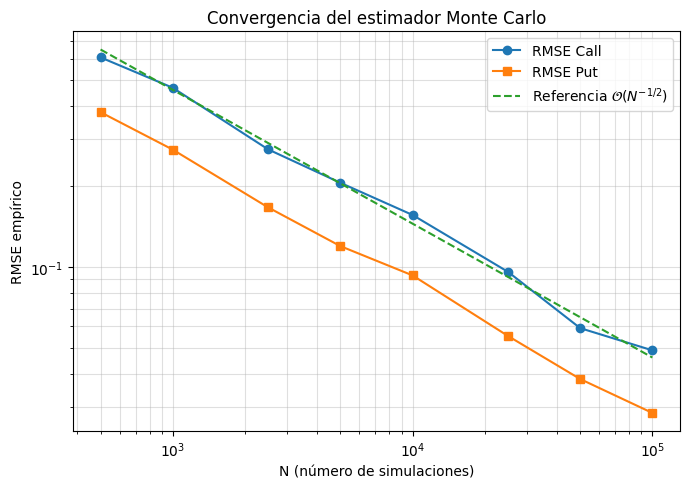

In [6]:
# Reescalamos la curva 1/sqrt(N) para que pase por el primer punto
scale = np.mean(df_conv["RMSE_call"] * np.sqrt(df_conv["N"]))

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(df_conv["N"], df_conv["RMSE_call"], "o-", label="RMSE Call")
ax.loglog(df_conv["N"], df_conv["RMSE_put"],  "s-", label="RMSE Put")
ax.loglog(df_conv["N"], scale/np.sqrt(df_conv["N"]), "--",
          label=r"Referencia $\mathcal{O}(N^{-1/2})$")

ax.set_xlabel("N (número de simulaciones)")
ax.set_ylabel("RMSE empírico")
ax.set_title("Convergencia del estimador Monte Carlo")
ax.grid(True, which="both", alpha=0.4)
ax.legend()
plt.tight_layout()
plt.show()

**Lectura.** El RMSE empírico decrece de forma paralela a la curva de referencia $\mathcal{O}(N^{-1/2})$, lo que confirma la tasa de convergencia prevista por el teorema central del límite. La pendiente de las tres rectas en escala log–log es próxima a $-1/2$.

## 5. Verificación numérica de la paridad put–call

La paridad put–call establece, para opciones europeas sobre un activo sin dividendos,

$$C(S_0,K,T) - P(S_0,K,T) = S_0 - K e^{-rT}.$$

A nivel de **trayectoria individual** se cumple la identidad determinista

$$(S_T - K)^+ - (K - S_T)^+ = S_T - K, \qquad \forall\, S_T \in \mathbb{R}_+,$$

de la cual se deduce, descontando, $e^{-rT}\bigl[(S_T-K)^+ - (K-S_T)^+\bigr] = e^{-rT}(S_T - K)$. Esta igualdad se cumple muestra a muestra y se utiliza como comprobación de consistencia interna del código.

A nivel de **estimadores agregados**, en cambio, $C_{MC} - P_{MC}$ aproxima $S_0 - Ke^{-rT}$ solo dentro de la precisión Monte Carlo.

In [7]:
rng = np.random.default_rng(SEED)
Z = rng.normal(0.0, 1.0, 100000)
ST = simulate_ST_exact(Z, T, r, sigma, S0)

# (a) Paridad muestra a muestra (debe coincidir)
payoff_call = np.maximum(ST - K, 0.0)
payoff_put  = np.maximum(K - ST, 0.0)
diff_pathwise = np.exp(-r*T) * ((payoff_call - payoff_put) - (ST - K))

print("(a) Paridad muestra a muestra:")
print(np.max(np.abs(diff_pathwise)))

# (b) Paridad en el agregado (precisión Monte Carlo)
c_mc, c_se = MC_price("call", ST, K, r, T)
p_mc, p_se = MC_price("put",  ST, K, r, T)

paridad_teorica = S0 - K * np.exp(-r * T)
paridad_mc      = c_mc - p_mc

# El error estándar de la diferencia se obtiene del estimador conjunto
diff_paths = np.exp(-r*T) * (payoff_call - payoff_put)
se_diff = np.std(diff_paths, ddof=1) / np.sqrt(len(diff_paths))

print(f"\n(b) Paridad en el agregado:")
print(f"    S_0 - K e^(-rT)        = {paridad_teorica:.6f}")
print(f"    C_MC - P_MC            = {paridad_mc:.6f}")
print(f"    Discrepancia           = {abs(paridad_teorica - paridad_mc):.2e}")
print(f"    Error estándar diff.   = {se_diff:.2e}")
print(f"    Discrepancia / SE      = {abs(paridad_teorica - paridad_mc)/se_diff:.2f}  (esperado O(1))")

(a) Paridad muestra a muestra:
0.0

(b) Paridad en el agregado:
    S_0 - K e^(-rT)        = 4.877058
    C_MC - P_MC            = 4.888212
    Discrepancia           = 1.12e-02
    Error estándar diff.   = 6.38e-02
    Discrepancia / SE      = 0.17  (esperado O(1))


**Lectura.**
- (a) La paridad put--call se satisface trayectoria a trayectoria, con una discrepancia numérica nula a efectos prácticos. Esto verifica que las payoffs de la call yla put se han calculado sobre las mismas realizaciones simuladas de $S_T$.
- (b) A nivel agregado, la diferencia $C_{MC} - P_{MC}$ no coincide exactamente con$S_0 - Ke^{-rT}$, sino que presenta una discrepancia pequeña y compatible con el error estándar estimado. En consecuencia, la desviación observada puede atribuirse al ruido estadístico propio del método Monte Carlo, y no a un sesgo sistemático de la implementación.

## 6. Conclusiones

1. El estimador Monte Carlo del precio recupera el valor analítico de Black–Scholes dentro del intervalo de confianza al 95% para $N = 10^5$ simulaciones.
2. El RMSE empírico decrece a tasa $\mathcal{O}(N^{-1/2})$, en línea con la predicción del teorema central del límite.
3. La paridad put–call se satisface a precisión de máquina cuando ambos estimadores comparten las trayectorias subyacentes.

Con estos tres resultados validamos la implementación del estimador Monte Carlo y son el punto de partida para los notebooks posteriores.